# 02 &mdash; Statistical Tests: Diebold-Mariano and the Model Confidence Set

Notebook 01 produced per-origin MAE for each of the ten models at 60
evenly-spaced forecast origins. This notebook asks two rigorous
questions of that output:

1. **Diebold-Mariano (pairwise):** is each model significantly different
   from the RWD baseline in predictive accuracy?
2. **Model Confidence Set (joint):** which models are statistically
   indistinguishable from the best one, with a built-in correction for
   multiple comparisons?

These are complementary tools. DM gives familiar pairwise p-values;
MCS returns a *set* and handles the multiple-comparisons problem
that arises with ten models.

The CSVs written by notebook 01 are loaded directly; no re-running the
backtest.


## 1. Setup

In [ ]:
import sys
from pathlib import Path

# Make `coffee_forecast` importable whether or not `pip install -e .`
# is in effect for this kernel. No-op when the package is already on
# sys.path (e.g. via the editable install); falls back to inserting
# the repo root so the notebook also runs from a fresh clone.
try:
    import coffee_forecast  # noqa: F401
except ModuleNotFoundError:
    sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

from coffee_forecast import diebold_mariano_test, model_confidence_set
from coffee_forecast.config import COLOR_MAP, CSV_DIR, FIG_DIR, SEED, REPO_ROOT

FIG_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load the 60-origin results

We work exclusively at scale = 60 in this notebook. The smaller scales
(1, 10, 30) are useful as robustness checks but dilute the main
statistical story.

In [2]:
summary = pd.read_csv(CSV_DIR / "summary_all_scales.csv")
results_60 = summary[summary["scale"] == 60].copy()

n_models = results_60["model"].nunique()
n_origins = results_60["origin_id"].nunique()
print(f"Loaded {len(results_60)} rows: {n_models} models × {n_origins} origins.")

Loaded 600 rows: 10 models × 60 origins.


## 3. Leaderboard

Mean metrics across the 60 origins, sorted by MAE. This is the
descriptive table &mdash; the "what happened" summary that every later
analysis zooms into.

In [3]:
leaderboard = (
    results_60.groupby("model")[["MAE", "RMSE", "MASE", "sMAPE"]]
    .mean()
    .sort_values("MAE")
)

leaderboard.to_csv(CSV_DIR / "final_leaderboard_60.csv")
print("Saved:", (CSV_DIR / "final_leaderboard_60.csv").relative_to(REPO_ROOT))
leaderboard[["MAE", "RMSE", "sMAPE"]].round(3)

Saved: results/csv/final_leaderboard_60.csv


,MAE,RMSE,sMAPE
model,,,
RWD,12.789,14.841,0.083
ETS,12.819,14.893,0.085
Theta,12.862,14.934,0.085
Naive,12.909,14.986,0.085
RF,13.132,15.188,0.087
ARIMA,13.239,15.385,0.085
GARCH,13.505,15.740,0.090
Granite-TTM,13.842,16.089,0.092
Ridge,14.682,17.160,0.101


RWD has the lowest mean MAE, followed by the other simple baselines
(ETS, Theta, Naïve) within 0.15 MAE of it. Prophet sits well outside
the cluster. The statistical tests below determine which of these
gaps are distinguishable from sampling noise.

## 4. Diebold-Mariano vs. RWD

Tests the null hypothesis that each model has equal predictive accuracy
to the RWD baseline. The loss series is per-origin MAE (one number per
forecast origin, 60 total), and HAC variance is estimated across origins
using the Bartlett kernel with the Newey-West (1994) rule-of-thumb
bandwidth $\lfloor 4 (T/100)^{2/9} \rfloor$. The Harvey-Leybourne-Newbold
(1997) small-sample correction is applied to reduce over-rejection at
T=60: the statistic is multiplied by $\sqrt{(T+1-2h+h(h-1)/T)/T}$ (with
$h = 1$ this is $\sqrt{(T-1)/T}$) and referenced against the Student-$t$
distribution with $T-1$ degrees of freedom rather than $\mathcal{N}(0,1)$.

- **Positive DM statistic**  => the model is *worse* than RWD
- **Negative DM statistic**  => the model is *better* than RWD
- Two-sided p-value under $\mathrm{DM} \sim t(T-1)$


In [ ]:
# Per-origin MAE dict, ordered by origin_id so the HAC lags line up chronologically.
losses = {
    m: results_60[results_60["model"] == m].sort_values("origin_id")["MAE"].values
    for m in results_60["model"].unique()
}

model_order = leaderboard.index.tolist()  # leaderboard order (best → worst)
rwd_mae = leaderboard.loc["RWD", "MAE"]

dm_results = {}
rows = []
for m in model_order:
    if m == "RWD":
        rows.append(
            {
                "Model": "RWD",
                "Mean MAE": rwd_mae,
                "Δ vs RWD": 0.0,
                "DM stat": None,
                "p-value": None,
                "sig": "(baseline)",
            }
        )
        continue
    dm_stat, p_val = diebold_mariano_test(losses[m], losses["RWD"])
    dm_results[m] = (dm_stat, p_val)
    sig = (
        "***"
        if p_val < 0.001
        else (
            "**"
            if p_val < 0.01
            else "*" if p_val < 0.05 else "†" if p_val < 0.10 else "ns"
        )
    )
    rows.append(
        {
            "Model": m,
            "Mean MAE": leaderboard.loc[m, "MAE"],
            "Δ vs RWD": leaderboard.loc[m, "MAE"] - rwd_mae,
            "DM stat": dm_stat,
            "p-value": p_val,
            "sig": sig,
        }
    )

dm_table = pd.DataFrame(rows).set_index("Model")
print(
    "Significance:  † p<0.10   * p<0.05   ** p<0.01   *** p<0.001   ns = not significant"
)
dm_table.round(4)

Significance:  † p<0.10   * p<0.05   ** p<0.01   *** p<0.001   ns = not significant


,Mean MAE,Δ vs RWD,DM stat,p-value,sig
Model,,,,,
RWD,12.7889,0.0000,NaN,NaN,(baseline)
ETS,12.8187,0.0298,0.1651,0.8694,ns
Theta,12.8620,0.0731,0.6550,0.5150,ns
Naive,12.9092,0.1203,0.7562,0.4525,ns
RF,13.1320,0.3432,0.5374,0.5930,ns
ARIMA,13.2394,0.4505,1.5235,0.1330,ns
GARCH,13.5048,0.7159,1.7609,0.0834,†
Granite-TTM,13.8416,1.0527,2.3526,0.0220,*
Ridge,14.6819,1.8930,2.0401,0.0458,*


Three patterns in the table:

- **None of the top-tier simple models differ significantly from RWD.**
  ETS, Theta, and Naive all have p > 0.4. The gaps between them fall
  within sampling noise.
- **Granite-TTM is significantly worse than RWD at the 5% level**
  (DM = +2.35, p = 0.022). Its 32-year pretraining and 1,536-day
  context window do not improve point accuracy relative to the drift
  baseline.
- **Prophet is rejected at the 0.1% level** (DM = +4.53, p < 0.001),
  consistent with its mean MAE of 22.7.

Note that DM tests each model against a single baseline (RWD) without
multiple-comparisons correction. The MCS in §5 is the proper joint
test.


## 5. Model Confidence Set

The DM test compares each model to a fixed baseline. The MCS asks the
joint question: *which subset of models contains the true best with
confidence* $1 - \alpha$?

Procedure (Hansen, Lunde & Nason, 2011):

1. Start with all ten models in the active set.
2. Compute the max-t statistic across centered loss differentials.
3. Bootstrap the null distribution (circular block bootstrap,
   $B = 5000$, block size 5) to obtain a p-value.
4. If $p \leq \alpha$, eliminate the model with the highest t-statistic
   and repeat. If not, stop: the active set is the MCS.

Models surviving in the MCS are jointly indistinguishable from the best
model at significance level $\alpha$. Per HLN, p-values reported for
eliminated models are monotonically adjusted (the running maximum across
elimination steps), so a model eliminated later cannot have a smaller
MCS p-value than one eliminated earlier.

**Note on power.** $T = 60$ origins is on the small side for MCS (HLN's
simulations use $T = 100$&ndash;$500$). With $T = 60$ and ten models the
test has limited power, so a wider-than-true MCS is partly a power
story rather than purely a true-tie story. The qualitative finding
below (Prophet eliminated; the other nine retained) is robust, but the
surviving-9-model set could plausibly shrink with more origins.

In [5]:
print("Running Model Confidence Set (alpha=0.10, block bootstrap B=5000)...")
mcs_models, mcs_df = model_confidence_set(
    losses, alpha=0.10, block_size=5, n_boot=5000, seed=SEED
)

print(f"\nMCS at α = 0.10  ({len(mcs_models)} of {len(losses)} models):")
print("  " + ", ".join(mcs_models))

excluded = [m for m in losses if m not in mcs_models]
print(f"\nExcluded ({len(excluded)}): {', '.join(excluded)}")

mcs_df

Running Model Confidence Set (alpha=0.10, block bootstrap B=5000)...

MCS at α = 0.10  (9 of 10 models):
  Naive, RWD, Theta, ETS, ARIMA, GARCH, Ridge, RF, Granite-TTM

Excluded (1): Prophet


,model,mcs_p_value,in_mcs
0,Naive,1.0000,True
1,RWD,1.0000,True
2,Theta,1.0000,True
3,ETS,1.0000,True
4,ARIMA,1.0000,True
5,GARCH,1.0000,True
6,Ridge,1.0000,True
7,RF,1.0000,True
8,Granite-TTM,1.0000,True
9,Prophet,0.0088,False


## 6. Visualization: `dm_mcs.png`

A two-panel figure summarizing both tests.

**Left panel:** DM p-values vs. RWD, color-coded by significance level.
**Right panel:** mean MAE at 60 origins with MCS membership marked &mdash;
survivors as filled circles, eliminated models as red x's, and the
full MCS range shaded green.

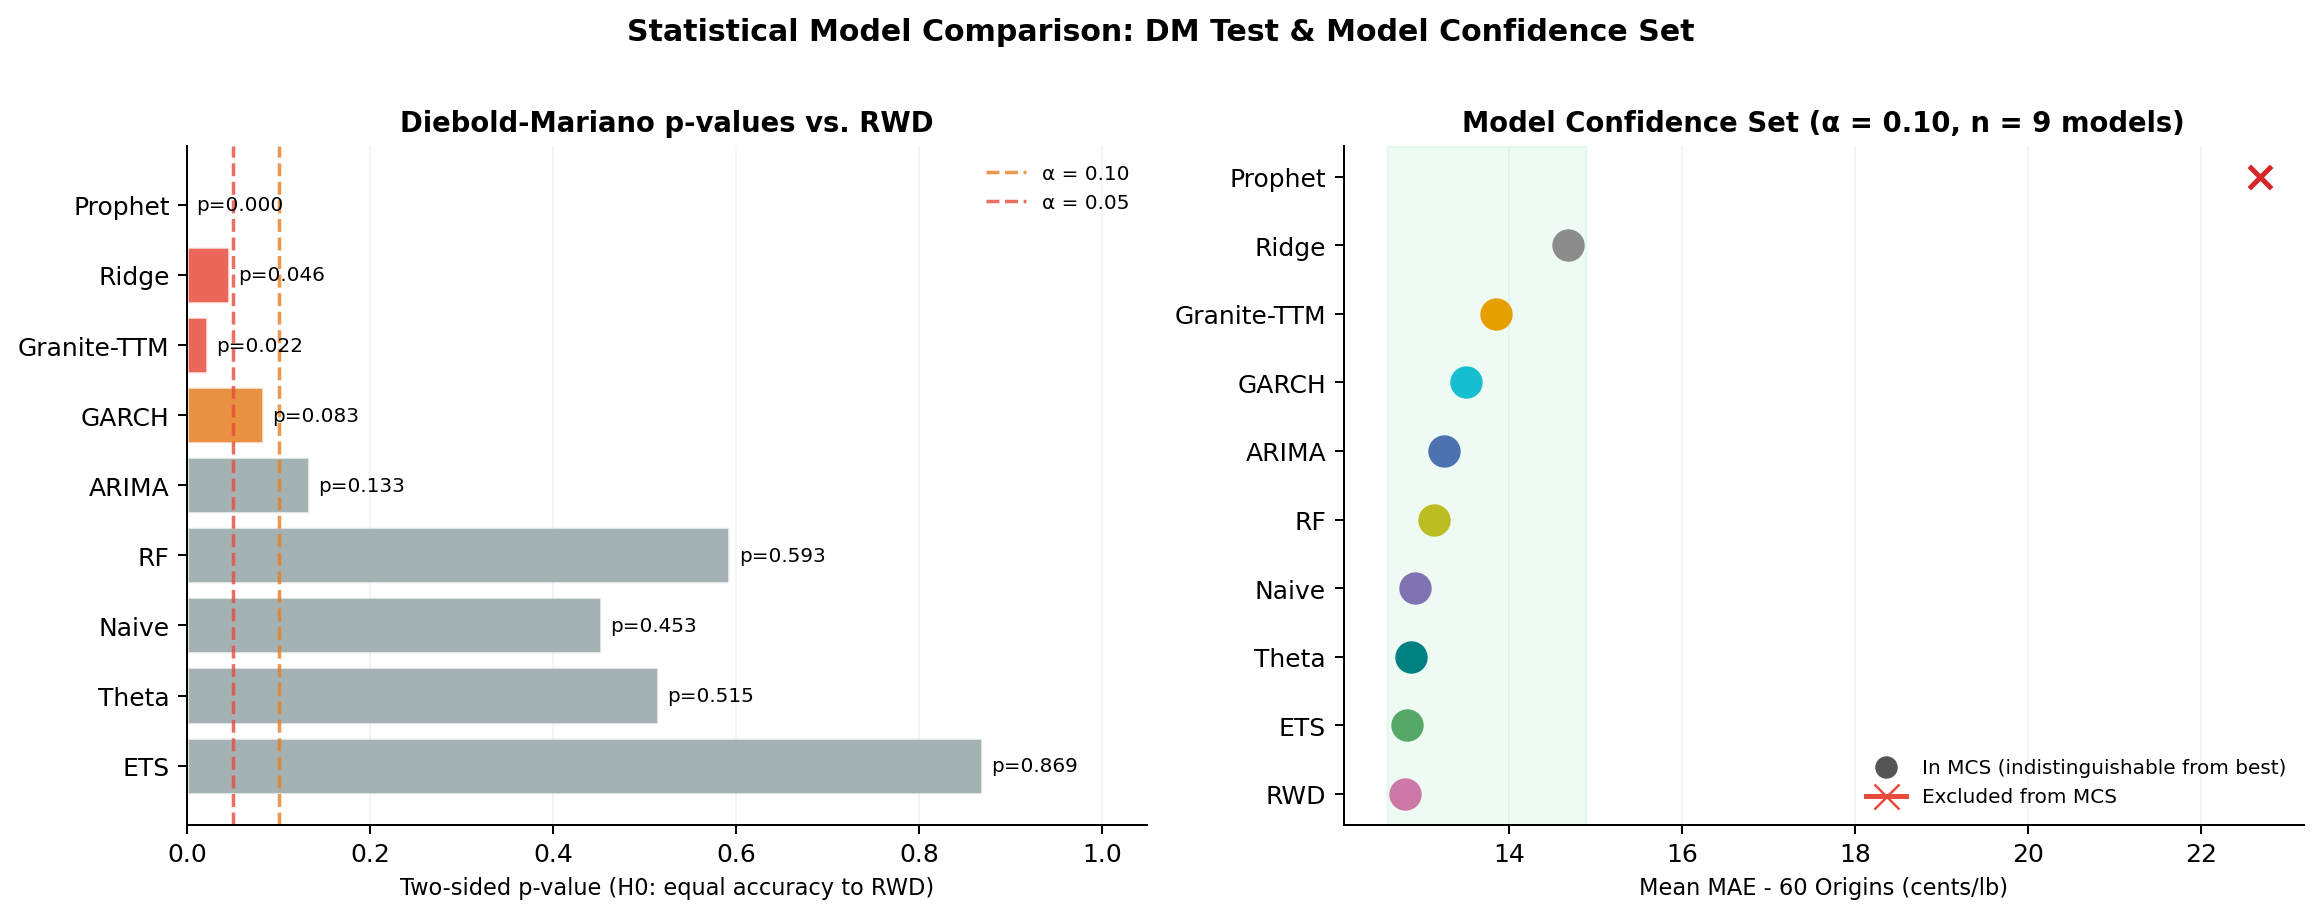

Saved: results/figures/dm_mcs.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=180)

# ===== Left: DM p-values vs RWD =====
ax = axes[0]
dm_models = [m for m in model_order if m != "RWD"]
dm_pvals = [dm_results[m][1] for m in dm_models]
bar_colors = [
    (
        "#E74C3C"
        if p < 0.05
        # significant
        else (
            "#E67E22"
            if p < 0.10
            # marginal
            else "#95A5A6"
        )
    )  # not significant
    for p in dm_pvals
]

bars = ax.barh(dm_models, dm_pvals, color=bar_colors, alpha=0.85, edgecolor="white")
ax.axvline(0.10, color="#E67E22", lw=1.4, ls="--", alpha=0.8, label="α = 0.10")
ax.axvline(0.05, color="#E74C3C", lw=1.4, ls="--", alpha=0.8, label="α = 0.05")
for bar, p in zip(bars, dm_pvals):
    ax.text(
        min(p + 0.01, 0.95),
        bar.get_y() + bar.get_height() / 2,
        f"p={p:.3f}",
        va="center",
        fontsize=8,
    )

ax.set_title("Diebold-Mariano p-values vs. RWD", fontsize=11, weight="semibold")
ax.set_xlabel("Two-sided p-value (H0: equal accuracy to RWD)", fontsize=9)
ax.set_xlim(0, 1.05)
ax.legend(fontsize=8, frameon=False)
ax.grid(True, axis="x", alpha=0.12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ===== Right: MCS membership dot plot =====
ax = axes[1]
mcs_plot = mcs_df.copy()
mcs_plot["mean_mae"] = [
    leaderboard.loc[m, "MAE"] if m in leaderboard.index else np.nan
    for m in mcs_plot["model"]
]
mcs_plot = mcs_plot.sort_values("mean_mae")

for _, row in mcs_plot.iterrows():
    color = COLOR_MAP.get(row["model"], "#666666")
    marker = "o" if row["in_mcs"] else "x"
    size = 120 if row["in_mcs"] else 80
    zorder = 4 if row["in_mcs"] else 3
    ax.scatter(
        row["mean_mae"],
        row["model"],
        color=color,
        marker=marker,
        s=size,
        linewidths=2.0,
        zorder=zorder,
    )

# Shade the MCS range so the "top tier" is visually obvious.
mcs_maes = mcs_plot[mcs_plot["in_mcs"]]["mean_mae"]
if len(mcs_maes) > 0:
    ax.axvspan(
        mcs_maes.min() - 0.2,
        mcs_maes.max() + 0.2,
        color="#2ECC71",
        alpha=0.08,
        label="MCS range",
    )

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="#555",
        markersize=10,
        label="In MCS (indistinguishable from best)",
    ),
    Line2D(
        [0],
        [0],
        marker="x",
        color="#E74C3C",
        markersize=10,
        linewidth=2,
        label="Excluded from MCS",
    ),
]
ax.legend(handles=legend_elements, fontsize=8, frameon=False, loc="lower right")
ax.set_title(
    f"Model Confidence Set (α = 0.10, n = {len(mcs_models)} models)",
    fontsize=11,
    weight="semibold",
)
ax.set_xlabel("Mean MAE - 60 Origins (cents/lb)", fontsize=9)
ax.grid(True, axis="x", alpha=0.12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.suptitle(
    "Statistical Model Comparison: DM Test & Model Confidence Set",
    fontsize=12,
    weight="semibold",
    y=1.01,
)
fig.tight_layout()
fig.savefig(FIG_DIR / "dm_mcs.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", (FIG_DIR / "dm_mcs.png").relative_to(REPO_ROOT))

## 7. Interpretation

DM and MCS look superficially contradictory: DM rejects equal
accuracy between RWD and Granite (p = 0.022) and Ridge (p = 0.046),
while MCS keeps all nine non-Prophet models in the confidence set
with p = 1. The gap is real and explainable. DM tests one pair at a
time without correction, so running nine pairwise tests against RWD
inflates Type I error; MCS tests the full set jointly and corrects
for multiple comparisons by construction. With ten models the joint
test is the appropriate primary tool; DM is a familiar pairwise
summary that supplements the joint result, not a contradiction of it.

The headline: 9 of 10 models are jointly indistinguishable from the
best at $\alpha = 0.10$; only Prophet is eliminated. The nine
survivors span every category in the model suite (simple baselines,
classical statistical, volatility, recursive ML, and the foundation
model), and the differences between them are not statistically
resolvable with 60 origins.

So the leaderboard numbers from §3 are descriptive, not a true
ranking. RWD isn't "the winner"; it's the arithmetic leader of a
cluster of statistically-equivalent models, and there isn't enough
signal that this suite can extract to produce one.

**Brewing conclusion.** A diverse 10-model suite &mdash; ranging
from random-walk baselines to a foundation model with 32 years of
pretraining &mdash; cannot statistically distinguish itself from
the naive drift forecaster on this series. That pattern has a
natural reading in financial economics: it's the empirical
fingerprint of *weak-form market efficiency* (Fama 1970), the
hypothesis that past prices alone contain no exploitable
information about future prices. But this argument has a hole
&mdash; maybe the suite is the wrong instrument and a different
class of models would extract structure that ours misses. Closing
that hole requires looking at the series itself, independently of
any model. That's what notebook 03 does.

---

**Next notebook:** [`03_stationarity_diagnostics.ipynb`](03_stationarity_diagnostics.ipynb)
&mdash; asks *why* the benchmark collapses into a statistical tie,
using the standard finance-econometrics battery (ADF / KPSS /
Phillips-Perron, Ljung-Box on returns, Lo-MacKinlay variance ratio).
